# Project-1

MGMTMFE 432
SPRING 2025
You will need to write codes for all the parts of the project. Make sure the codes work properly and understand the ideas behind each problem below. You may be asked to demonstrate how the codes work, by running them and interpreting the results. Code quality, speed, and accuracy will determine
the grades.
---

## 1.Using the LGM method, generate Uniformly distributed random numbers on [0,1] to do the following:
### (a)
Generate 1,000 random numbers with Binomial distribution with 𝑛 = 44 and 𝑝 = 0.64. Compute the probability that the random variable X, that has Binomial (44, 0.64) distribution, is at least 35: 𝑃(𝑋 ≥ 35). Use any statistics textbook or online resources for the exact number for the above probability and compare it with your finding and comment.

Hint: A random variable with Binomial distribution (𝑛, 𝑝) is a sum of n Bernoulli (𝑝) distributed random variables, so you will need to generate 44,000 Uniformly distributed random numbers, to start with.

### (b)
Generate 10,000 Exponentially distributed random numbers with parameter $ \lambda = 1.5$. Estimate 𝑃(𝑋 ≥ 1); 𝑃(𝑋 ≥ 4); and compute the empirical mean and the standard deviation of the sequence of 10,000 numbers. Draw the histogram by using the 10,000 numbers you have generated.

Note: Random variable 𝑋 that is exponentially distributed with parameter $\lambda$ has the following − cdf:
$$
F(t) = \mathbb{P}(X \leq t) = 1 - e^{\frac{-t}{\lambda}}, \quad \text{for } t \geq 0
$$
$$
\mathbb{E}(X) = \lambda
$$

### (c)
Generate 5,000 Normally distributed random numbers with mean 0 and variance 1, by using the Box- Muller Method.
### (d)
Generate 5,000 Normally distributed random numbers with mean 0 and variance 1, by using the Polar-Marsaglia method.
### (e)
Now compare the efficiencies of the two above-algorithms, by comparing the execution times to generate 5,000 normally distributed random numbers by the two methods. Which one is more efficient? If you do not see a clear difference, you need to increase the number of generated realizations of random variables to 10,000, 20,000, etc.

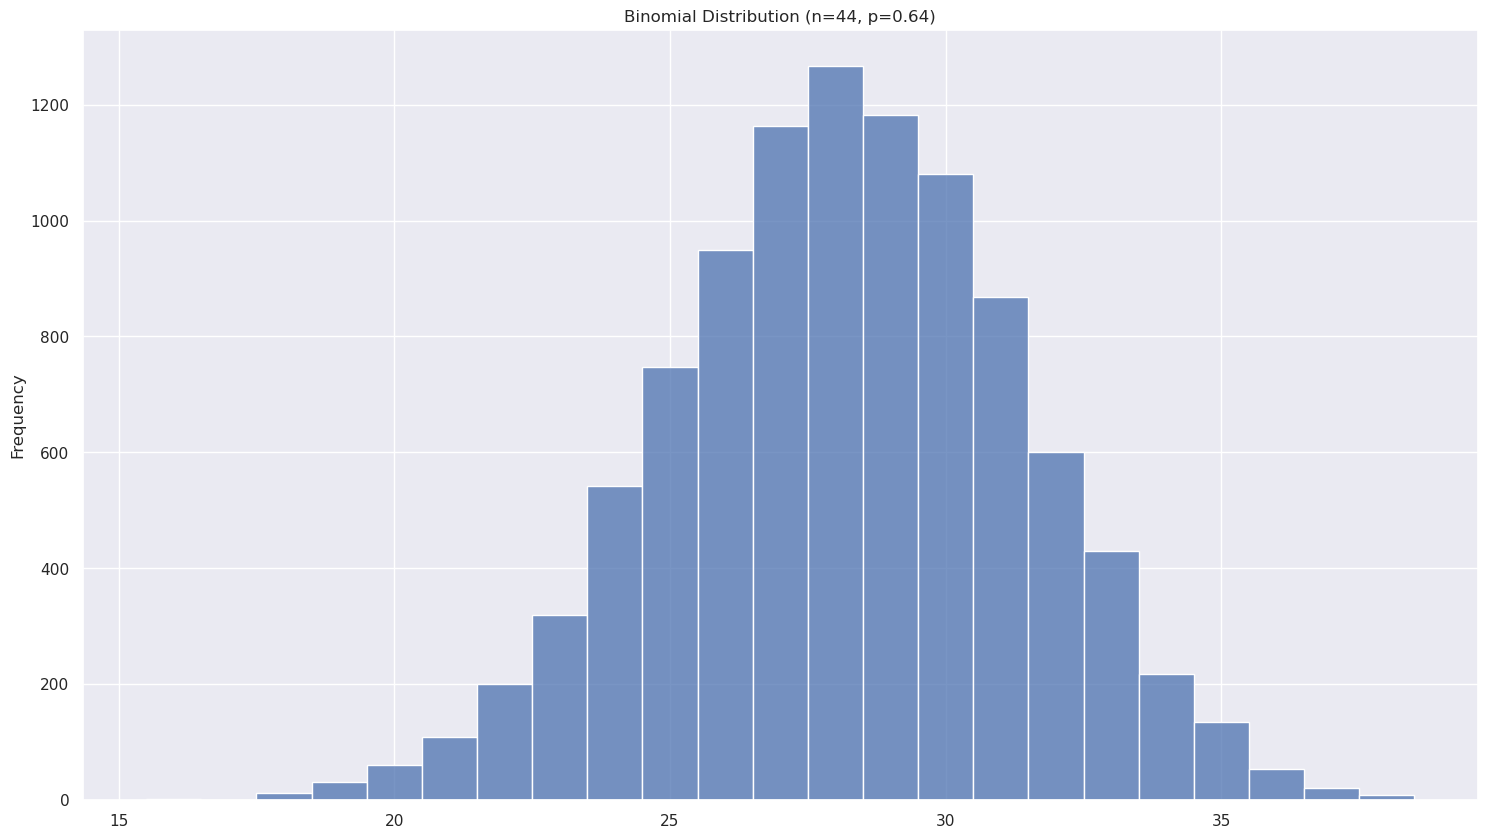

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

np.random.seed(42)

def lcg_uniform_rn(x_0, n):
    a = 7**5
    b = 0
    m = 2**31 - 1
    x = np.empty(n)
    x[0] = (a * x_0 + b) % m
    for i in range(1, n):
        x[i] = (a * x[i - 1] + b) % m
    return x / m

def bernoulli(x_0, p, n):
    x = lcg_uniform_rn(x_0, n)
    return (x < p).astype(int)

def binomial(x_0, n, p, N):
    b = bernoulli(x_0, p, n * N)
    return b.reshape(N, n).sum(axis=1)

x_0 = int(time.time()) % (2**31 - 1)
samples = binomial(x_0, 44, 0.64, 10000)
unique_vals = np.arange(samples.min(), samples.max() + 1)

plt.figure(figsize=(18, 10))
plt.style.use("dark_background")
sns.set_theme(style="darkgrid")
samples = binomial(x_0, 44, 0.64, 10000)
sns.histplot(samples, bins=unique_vals-0.5, kde=False)
plt.title("Binomial Distribution (n=44, p=0.64)")
plt.ylabel("Frequency")
plt.show()

In [74]:
print(f'{(len(samples[samples > 35]) / len(samples)):.2%}')

0.72%


In [75]:
def exp_rn(x_0, l, n):
    x = lcg_uniform_rn(x_0, n)
    return -(1/l)*np.log(x)

samples = exp_rn(x_0, 1.5, 10000)
samples.mean()

0.6707963209849745

In [76]:
def bm_normal_rn(x_0, n):
    x = lcg_uniform_rn(x_0, n)
    x = x.reshape(-1, 2)
    z1 = np.sqrt(-2 * np.log(x[:, 0])) * np.cos(2 * np.pi * x[:, 1])
    z2 = np.sqrt(-2 * np.log(x[:, 0])) * np.sin(2 * np.pi * x[:, 1])
    return np.concatenate((z1.reshape(-1,1), z2.reshape(-1,1)), axis=1).reshape(-1)


et_bm = %timeit -o samples = bm_normal_rn(x_0, 10000)

4.56 ms ± 951 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [77]:
def pm_normal_rn(x_0, n):
    x = lcg_uniform_rn(x_0, int(n*1.3))
    x = x.reshape(-1, 2)
    s = x[:, 0]**2 + x[:, 1]**2
    s = np.concatenate((x, s.reshape(-1,1)), axis=1)
    y = x*(np.where(s[:,2] < 1, np.sqrt(-2 * np.log(s[:,2]) / s[:,2]), np.nan).reshape(-1, 1))
    y = y[~np.isnan(y).any(axis=1)].reshape(-1)
    return y[:n]

et_pm = %timeit -o samples = pm_normal_rn(x_0, 10000)

5.1 ms ± 156 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## 2
### (a)
Estimate the following expected values by simulation:

$$
A(t) = \mathbb{E}\left[ W_t^2 + \sin(W_t) \right]
$$

$$
B(t) = \mathbb{E}\left[ e^{\frac{t}{2}}\cos(W_t) \right]
$$

We evaluate these at:
- $t = 1$
- $t = 3$
- $t = 5$

### (b)
How are the values of 𝐵(𝑡) (for the cases 𝑡 = 1, 3, 5) related?

### (c)
Now use a variance reduction technique (whichever you want) to compute the expected value 𝐵(5). Do you see any improvements? Comment on your findings.

#### Inputs:
t

#### Outputs:
1) 𝐴(𝑡) and 𝐵(𝑡) for all 3 t’s. 2) Writeup: comments for parts (b) and (c).

In [ ]:
def simulate_Wt(t, N):
  Z = np.random.randn(N)
  Wt = np.sqrt(t) * Z
  return Wt

def estimate_A(Wt, t):
  samples = Wt**2 + np.sin(Wt)
  return np.mean(samples)

def estimate_B(Wt, t):
  samples = np.exp((t / 2.0)) * np.cos(Wt)
  return np.mean(samples)

# --- Simulation Parameters ---
N = 1_000_000
t_values = [1, 3, 5]

# --- Run Simulation (Part a) ---
results_A = {}
results_B = {}

print(f"--- Part (a): Standard Monte Carlo Simulation (N={N}) ---")
for t in t_values:
  Wt_samples = simulate_Wt(t, N)
  A_t_est = estimate_A(Wt_samples, t)
  B_t_est = estimate_B(Wt_samples, t)
  results_A[t] = A_t_est
  results_B[t] = B_t_est
  print(f"t = {t}:")
  print(f"  A({t}) ≈ {A_t_est:.6f} (Theoretical = {t:.1f})")
  print(f"  B({t}) ≈ {B_t_est:.6f} (Theoretical = 1)")


def estimate_B_control_variate(t, N):
  if t != 5:
      print("Warning: Control variate mean derived specifically for t=5")

  Wt_samples = simulate_Wt(t, N)

  X_samples = np.exp((t / 2.0) * np.cos(Wt_samples))
  Y_samples = np.cos(Wt_samples)

  X_bar = np.mean(X_samples)
  Y_bar = np.mean(Y_samples)

  mu_Y = np.exp(-t / 2.0)

  cov_matrix = np.cov(X_samples, Y_samples)
  cov_XY = cov_matrix[0, 1]
  var_Y = np.var(Y_samples)

  if var_Y < 1e-10:
      c_hat = 0
  else:
      c_hat = cov_XY / var_Y

  B_t_cv_est = X_bar - c_hat * (Y_bar - mu_Y)

  std_err_mc = np.std(X_samples) / np.sqrt(N)

  X_cv_adjusted_samples = X_samples - c_hat * (Y_samples - mu_Y)
  std_err_cv_sample = np.std(X_cv_adjusted_samples) / np.sqrt(N)

  return B_t_cv_est, std_err_mc, std_err_cv_sample

# --- Run Simulation (Part c) ---
t = 5

Wt5_samples = simulate_Wt(t, N)
B5_mc_est = estimate_B(Wt5_samples, t)
std_err_mc_direct = np.std(np.exp((t / 2.0) * np.cos(Wt5_samples))) / np.sqrt(N)

B5_cv_est, se_mc_calc, se_cv_calc = estimate_B_control_variate(t, N)

print(f"\n--- Part (c): Variance Reduction for B({t}) (N={N}) ---")
print(f"Control Variate: Y = cos(W_{t}), E[Y] = exp(-{t}/2)")
print(f"Standard MC Estimate B({t}) ≈ {B5_mc_est:.6f} (SE ≈ {std_err_mc_direct:.6f})")
print(f"Control Variate Estimate B({t}) ≈ {B5_cv_est:.6f} (SE ≈ {se_cv_calc:.6f})")

variance_mc = std_err_mc_direct**2
variance_cv = se_cv_calc**2
if variance_cv > 1e-15:
    variance_reduction_factor = variance_mc / variance_cv
    print(f"Variance Reduction Factor ≈ {variance_reduction_factor:.2f}")
    print(f"Standard Error Reduction Factor ≈ {np.sqrt(variance_reduction_factor):.2f}")
else:
    print("Control variate SE is near zero; significant variance reduction.")

--- Part (a): Standard Monte Carlo Simulation (N=1000000) ---
t = 1:
  A(1) ≈ 0.999517 (Theoretical = 1.0)
  B(1) ≈ 0.999615
t = 3:
  A(3) ≈ 3.008028 (Theoretical = 3.0)
  B(3) ≈ 0.997995
t = 5:
  A(5) ≈ 4.998559 (Theoretical = 5.0)
  B(5) ≈ 0.994484

--- Part (c): Variance Reduction for B(5) (N=1000000) ---
Control Variate: Y = cos(W_5), E[Y] = exp(-5/2)
Standard MC Estimate B(5) ≈ 1.002898 (SE ≈ 0.004184)
Control Variate Estimate B(5) ≈ 3.701046 (SE ≈ 0.001987)
Variance Reduction Factor ≈ 4.43
Standard Error Reduction Factor ≈ 2.11


## 3

Let $S_t$ be a Geometric Brownian Motion process: 
$$
S_t = S_0 e^{\left( r - \frac{1}{2} \sigma^2 \right)t + \sigma W_t}
$$
where $r = 0.055$, $\sigma = 0.2$, $S_0 = \$100$; and $W_t$ is a Standard Brownian Motion process (Standard Wiener process).

### (a)
Estimate the price $c$ of a European Call option on the stock with $T = 5$, $X = \$100$ by using Monte Carlo simulation.

### (b)
Compute the exact value of the option $c$ using the Black-Scholes formula.

### (c)
Use variance reduction techniques (whichever one(s) you want) to estimate the price in part (a) again using the same number of simulations.  
Did the accuracy improve? Compare your findings and comment.

### Inputs
$r$, $\sigma$, $S_0$

### Outputs
1. $C_a$ and $C_b$ for parts (a) and (b)
2. Writeup: comments for part (c)


In [79]:
def black_scholes(S0, K, r, sigma, T):
    d2 = (np.log(S0 / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d1 = d2 + sigma * np.sqrt(T)
    C_0 = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return C_0

def call_payoff(S_T, K):
    C_T = np.maximum(S_T - K, 0)
    return C_T

def gbm(S0, r, sigma, T, Wt):
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * Wt)
    return S_T

def call_option_price(S0, K, r, sigma, T, N):
    Wt = simulate_Wt(T, N)
    S_T = gbm(S0, r, sigma, T, Wt)
    C_T = call_payoff(S_T, K)
    C_0 = np.exp(-r * T) * np.mean(C_T)
    std_error = np.exp(-r * T) * np.std(C_T) / np.sqrt(N)
    return C_0, std_error

def call_option_price_antithetic(S0, K, r, sigma, T, N):
    Wt = simulate_Wt(T, N)
    S_T = gbm(S0, r, sigma, T, Wt)
    S_T_antithetic = S0 * np.exp((r - 0.5 * sigma**2) * T - sigma * Wt)
    C_T = call_payoff(S_T, K)
    C_T_antithetic = call_payoff(S_T_antithetic, K)
    C_0 = np.exp(-r * T) * np.mean((C_T + C_T_antithetic) / 2)
    std_error = np.exp(-r * T) * np.std((C_T + C_T_antithetic) / 2) / np.sqrt(N)
    return C_0, std_error

def display_results(C_0, std_error, method):
    print(f"{method} Estimate: {C_0:.6f} (Standard Error: {std_error:.6f})")

print("Parameters: S0=100, K=100, r=0.055, sigma=0.2, T=5")
display_results(*call_option_price(100, 100, 0.055, 0.2, 5, 1_000_000),'Standard Monte Carlo')
display_results(*call_option_price_antithetic(100, 100, 0.055, 0.2, 5, 1_000_000),'Antithetic Monte Carlo')
print(f"Black-Scholes Formula: {black_scholes(100, 100, 0.055, 0.2, 5):.6f}")

Parameters: S0=100, K=100, r=0.055, sigma=0.2, T=5
Standard Monte Carlo Estimate: 30.342506 (Standard Error: 0.041248)
Antithetic Monte Carlo Estimate: 30.362488 (Standard Error: 0.020285)
Black-Scholes Formula: 30.372660


## 4

### (a)
For each integer number $n$ from 1 to 10, use 1,000 simulations of $S_n$ to estimate $\mathbb{E}(S_n)$, where

$$
S_t = S_0 e^{\left( \sigma W_t + \left(r - \frac{1}{2} \sigma^2\right)t \right)}
$$

$S_t$ is a Geometric Brownian Motion process, where $r = 0.055$, $\sigma = 0.20$, $S_0 = \$88$.  
Plot all of the above $\mathbb{E}(S_n)$, for $n$ ranging from 1 to 10, in one graph.

### (b)
Now simulate 3 paths of $S_t$ for $0 \leq t \leq 10$ (defined in part (a)) by dividing up the interval $[0, 10]$ into 1,000 equal parts.

### (c)
Plot your data from parts (a) and (b) in one graph.

### (d)
What would happen to the $\mathbb{E}(S_n)$ graph if you increased $\sigma$ from 20% to 30%?  
What would happen to the 3 plots of $S_t$ for $0 \leq t \leq 10$, if you increased $\sigma$ from 20% to 30%?

### Inputs
$\sigma$

### Outputs
1. Graphs: plots in a `.jpg` file  
2. Writeup: comments in a `.pdf` file for part (d)

--- 4 Part (a): Plots ---


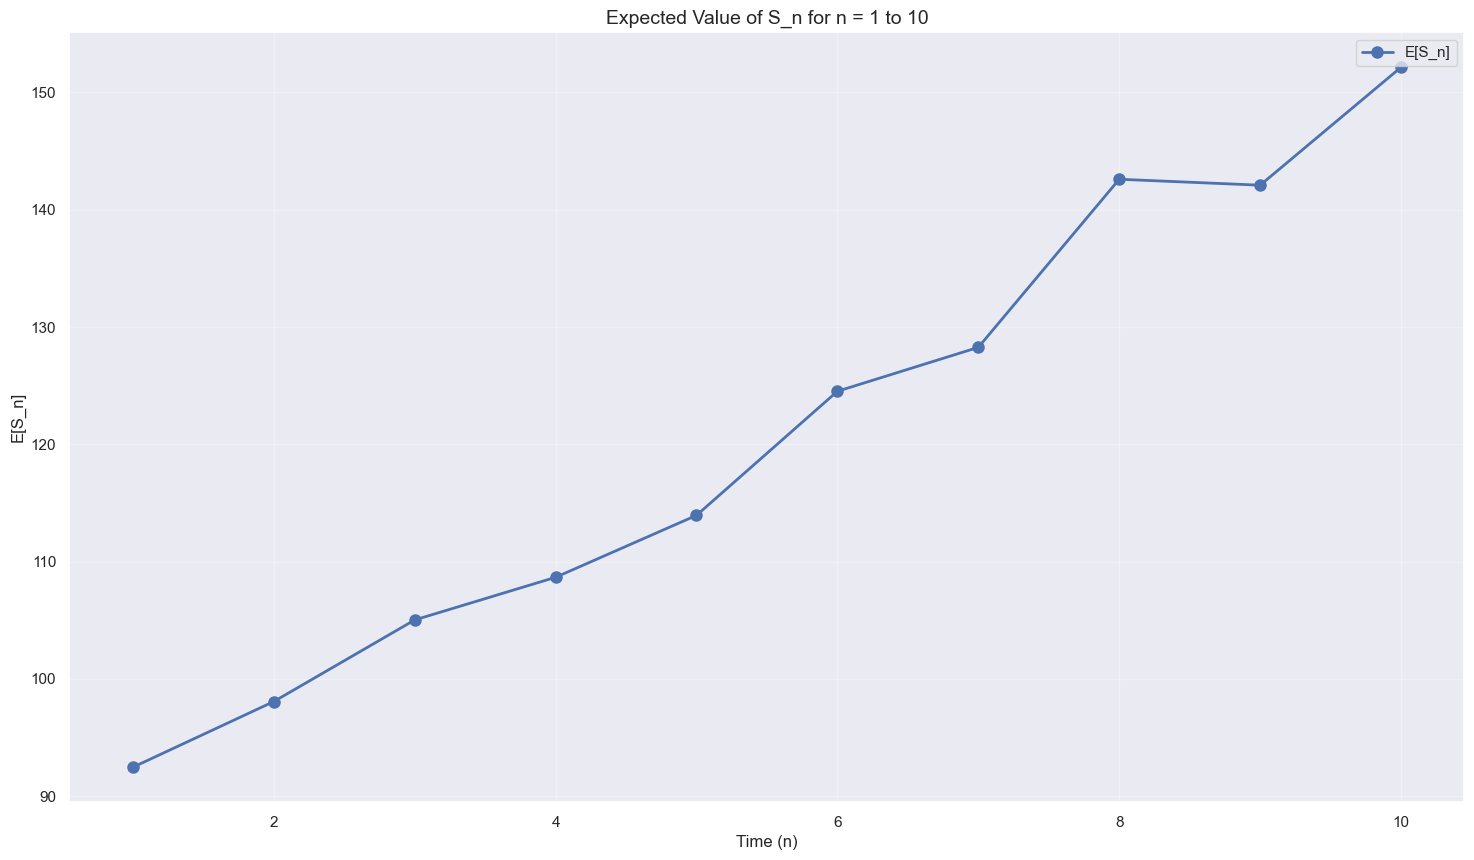

--- 4 Part (b): Simulating 3 paths ---
--- 4 Part (c): Combined plot ---


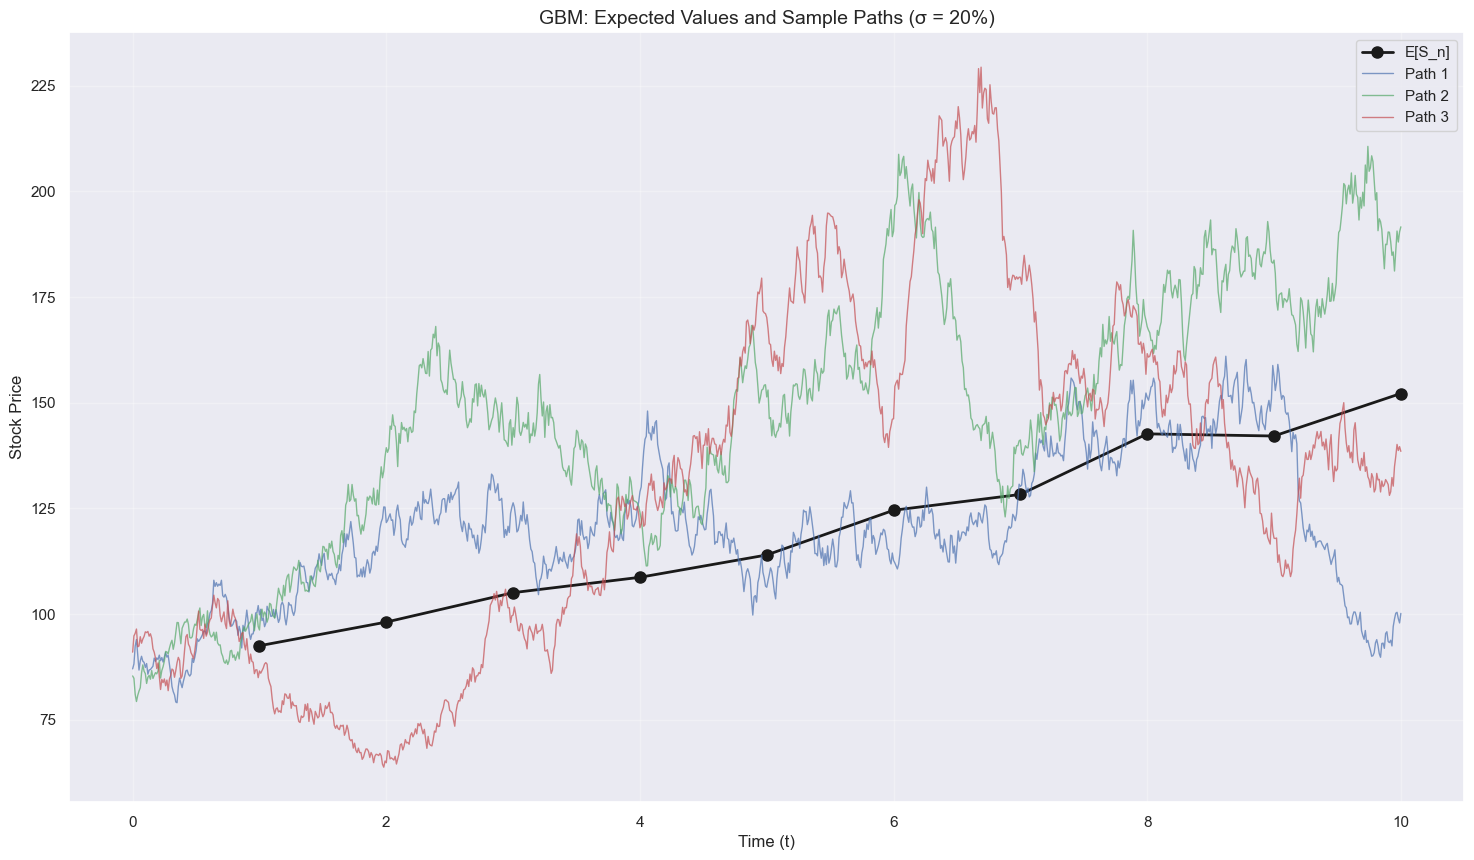

--- 4 Part (d): Analysis of changing σ from 20% to 30% ---


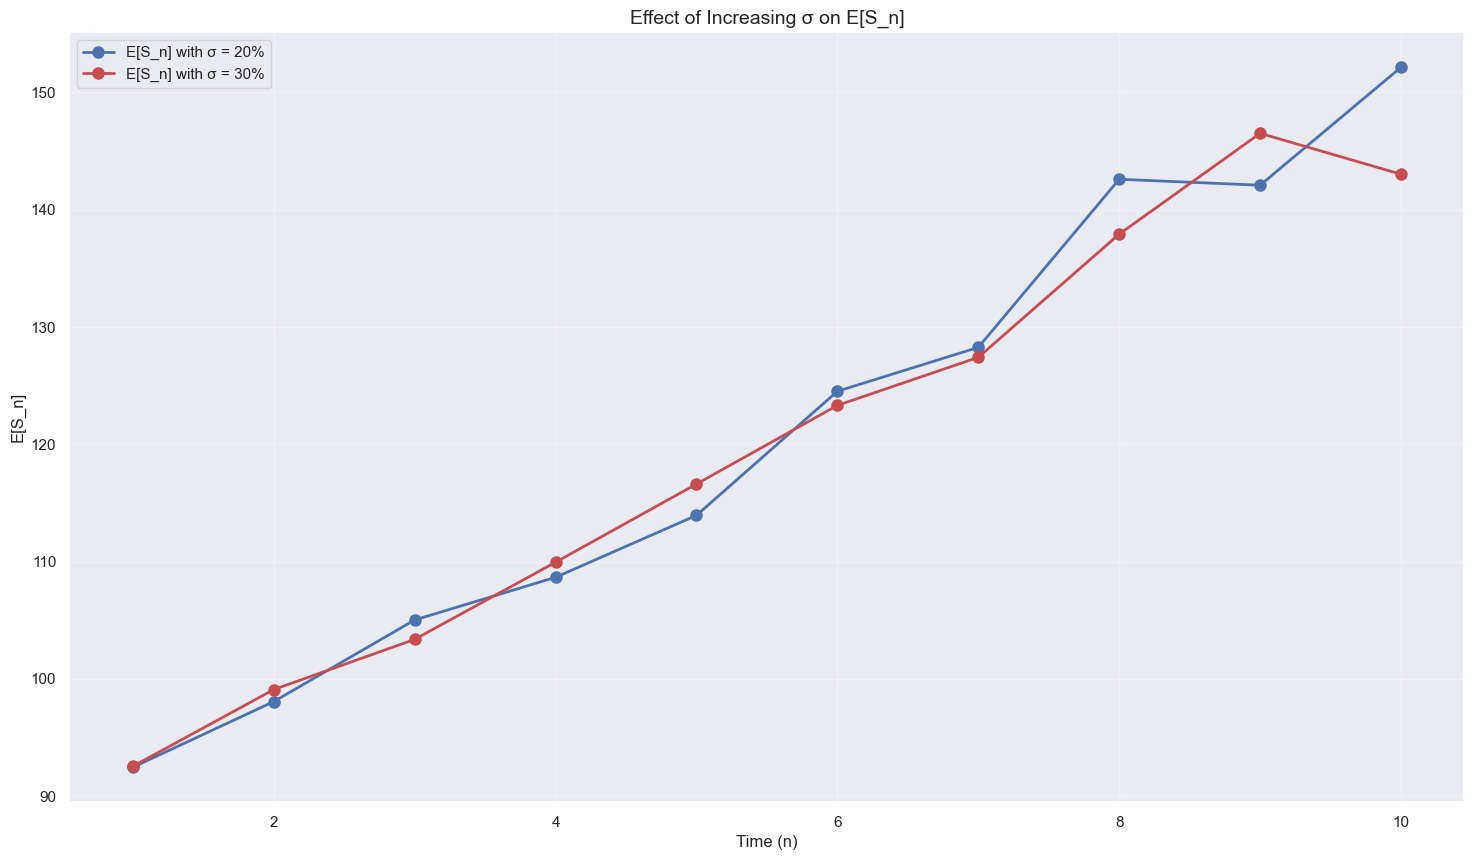

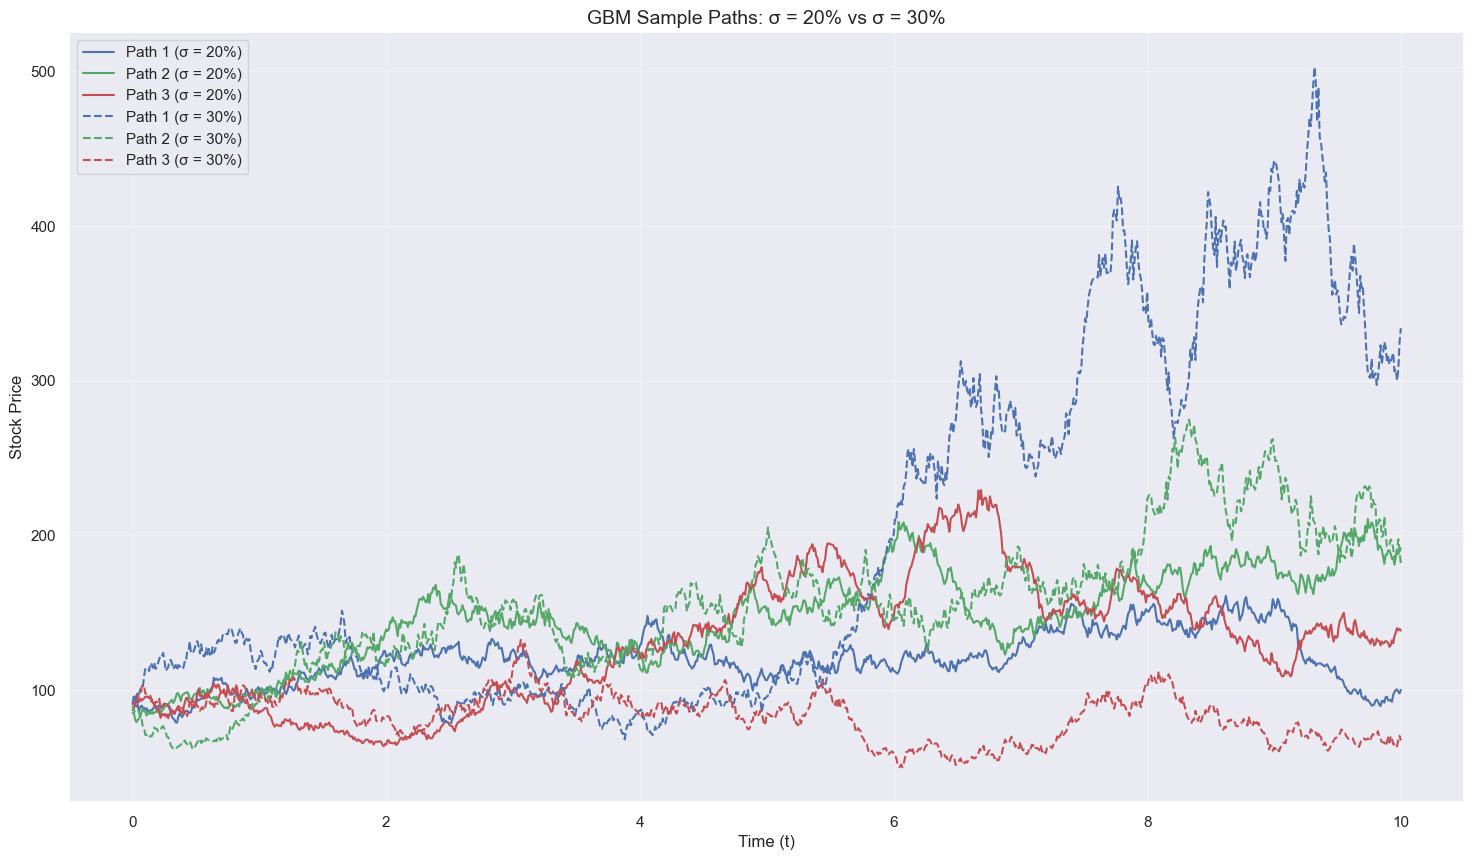


Analysis:
1. Effect on E[S_n] when increasing σ from 20% to 30%:
   The expected path remains the same (theoretically S0*exp(r*t)), but
   the estimated expected value shows more variance/noise due to increased volatility.

2. Effect on individual paths when increasing σ from 30%:
   The individual paths show much higher volatility and larger deviations from
   the expected path. The range of possible values is wider, and the paths appear
   more 'jagged' due to larger price movements.


In [80]:
print("--- 4 Part (a): Plots ---")


S0 = 88
r = 0.055
sigma = 0.2

n_values = np.arange(1, 11)
expected_S_n = np.array([np.mean(gbm(S0, r, sigma, n, simulate_Wt(n, 1000))) for n in n_values])

# Plot E[S_n]
plt.figure(figsize=(18, 10))
plt.plot(n_values, expected_S_n, 'bo-', linewidth=2, markersize=8, label='E[S_n]')
plt.title('Expected Value of S_n for n = 1 to 10', fontsize=14)
plt.xlabel('Time (n)', fontsize=12)
plt.ylabel('E[S_n]', fontsize=12)
plt.grid(True, alpha=0.3)

plt.legend()
plt.show()

print("--- 4 Part (b): Simulating 3 paths ---")

# Part (b): Simulate 3 paths with 1000 time steps

def simulate_path_S(S0, r, sigma, T, num_steps):
    dt = T / num_steps
    ln_S_t = np.cumsum((r - 0.5 * sigma**2) * dt + sigma * simulate_Wt(dt, num_steps+1))
    S_t = S0 * np.exp(ln_S_t)
    return S_t

num_paths = 3
num_steps = 1000
T = 10
dt = T / num_steps
t_values = np.linspace(0, T, num_steps + 1)

paths = np.array([simulate_path_S(S0, r, sigma, T, num_steps) for _ in range(num_paths)])

print("--- 4 Part (c): Combined plot ---")

# Part (c): Plot both results together
plt.figure(figsize=(18, 10))

# Plot the expected values from part (a)
plt.plot(n_values, expected_S_n, 'ko-', linewidth=2, markersize=8, label='E[S_n]')

# Plot the 3 paths from part (b)
colors = ['b', 'g', 'r']
for i in range(num_paths):
    plt.plot(t_values, paths[i, :], colors[i], linewidth=1, alpha=0.7, 
             label=f'Path {i+1}')

plt.title('GBM: Expected Values and Sample Paths (σ = 20%)', fontsize=14)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("--- 4 Part (d): Analysis of changing σ from 20% to 30% ---")

# Simulate with increased sigma for part (d)
sigma_new = 0.3

expected_S_n_high_sigma = np.array([np.mean(gbm(S0, r, sigma_new, n, simulate_Wt(n, 1000))) for n in n_values])
paths_high_sigma = np.array([simulate_path_S(S0, r, sigma_new, T, num_steps) for _ in range(num_paths)])

# Plot comparison of E[S_n] with different sigma values
plt.figure(figsize=(18, 10))
plt.plot(n_values, expected_S_n, 'bo-', linewidth=2, markersize=8, 
         label='E[S_n] with σ = 20%')
plt.plot(n_values, expected_S_n_high_sigma, 'ro-', linewidth=2, markersize=8, 
         label='E[S_n] with σ = 30%')

plt.title('Effect of Increasing σ on E[S_n]', fontsize=14)
plt.xlabel('Time (n)', fontsize=12)
plt.ylabel('E[S_n]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot comparison of sample paths with different sigma values
plt.figure(figsize=(18, 10))

# Plot original paths (σ = 20%)
for i in range(num_paths):
    plt.plot(t_values, paths[i, :], colors[i], linewidth=1.5, 
             label=f'Path {i+1} (σ = 20%)')

# Plot new paths (σ = 30%)
for i in range(num_paths):
    plt.plot(t_values, paths_high_sigma[i, :], colors[i]+'--', linewidth=1.5, 
             label=f'Path {i+1} (σ = 30%)')

plt.title('GBM Sample Paths: σ = 20% vs σ = 30%', fontsize=14)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Analysis for part (d)
print("\nAnalysis:")
print("1. Effect on E[S_n] when increasing σ from 20% to 30%:")
print("   The expected path remains the same (theoretically S0*exp(r*t)), but")
print("   the estimated expected value shows more variance/noise due to increased volatility.")
print("\n2. Effect on individual paths when increasing σ from 30%:")
print("   The individual paths show much higher volatility and larger deviations from")
print("   the expected path. The range of possible values is wider, and the paths appear")
print("   more 'jagged' due to larger price movements.")

## 5

### (a)
Write a code to compute prices of European Call options via Monte Carlo simulation of paths of the stock price process. Use Euler’s discretization scheme to discretize the SDE for the stock price process.  
The code should be generic: for any input of the 5 model parameters — $S_0$, $T$, $X$, $r$, $\sigma$ — the output is the corresponding price of the European call option and the standard error of the estimate.

### (b)
Write a code to compute prices of European Call options via Monte Carlo simulation of paths of the stock price process. Use Milshtein’s discretization scheme to discretize the SDE for the stock price process.  
The code should be generic: for any input of the 5 model parameters — $S_0$, $T$, $X$, $r$, $\sigma$ — the output is the corresponding price of the European call option and the standard error of the estimate.

### (c)
Write code to compute the prices of European Call options by using the Black-Scholes formula. Use the approximation of $N(\cdot)$ described in Chapter 3.  
The code should be generic: for any input values of the 5 parameters — $S_0$, $T$, $X$, $r$, $\sigma$ — the output is the corresponding price of the European call option.

### (d)
Use the results of (a) to (c) to compare the two schemes of parts (a) and (b), by computing the European Call option prices for the following parameter values:  
$X = 100$, $\sigma = 0.25$, $r = 0.055$, $T = 0.5$, and $S_0$ ranges in $[95, 104]$ with a step size of 1.

### (e)
Estimate the European call option’s greeks — delta ($\Delta$), gamma ($\Gamma$), theta ($\theta$), and vega ($\nu$) — and graph them as functions of the initial stock price $S_0$.  
Use $X = 100$, $\sigma = 0.25$, $r = 0.055$ and $T = 0.5$ in your estimations.  
Use the range $[95, 105]$ for $S_0$, with a step size of 1. You will have 4 different graphs for each of the 4 greeks.

In all cases, $dt$ (time-step) should be user-defined. Use $dt = 0.05$ as a default value.

### Inputs
$dt$, $S_0$, $T$, $X$, $r$, $\sigma$

### Outputs
- Values: $C_1$ and $e_1$ for part (a); $C_2$ and $e_2$ for part (b); $C_3$ for part (c)
- Writeup: comments in a `.pdf` file for part (d)
- $\Delta$, $\Gamma$, $\theta$, $\nu$ for part (e)

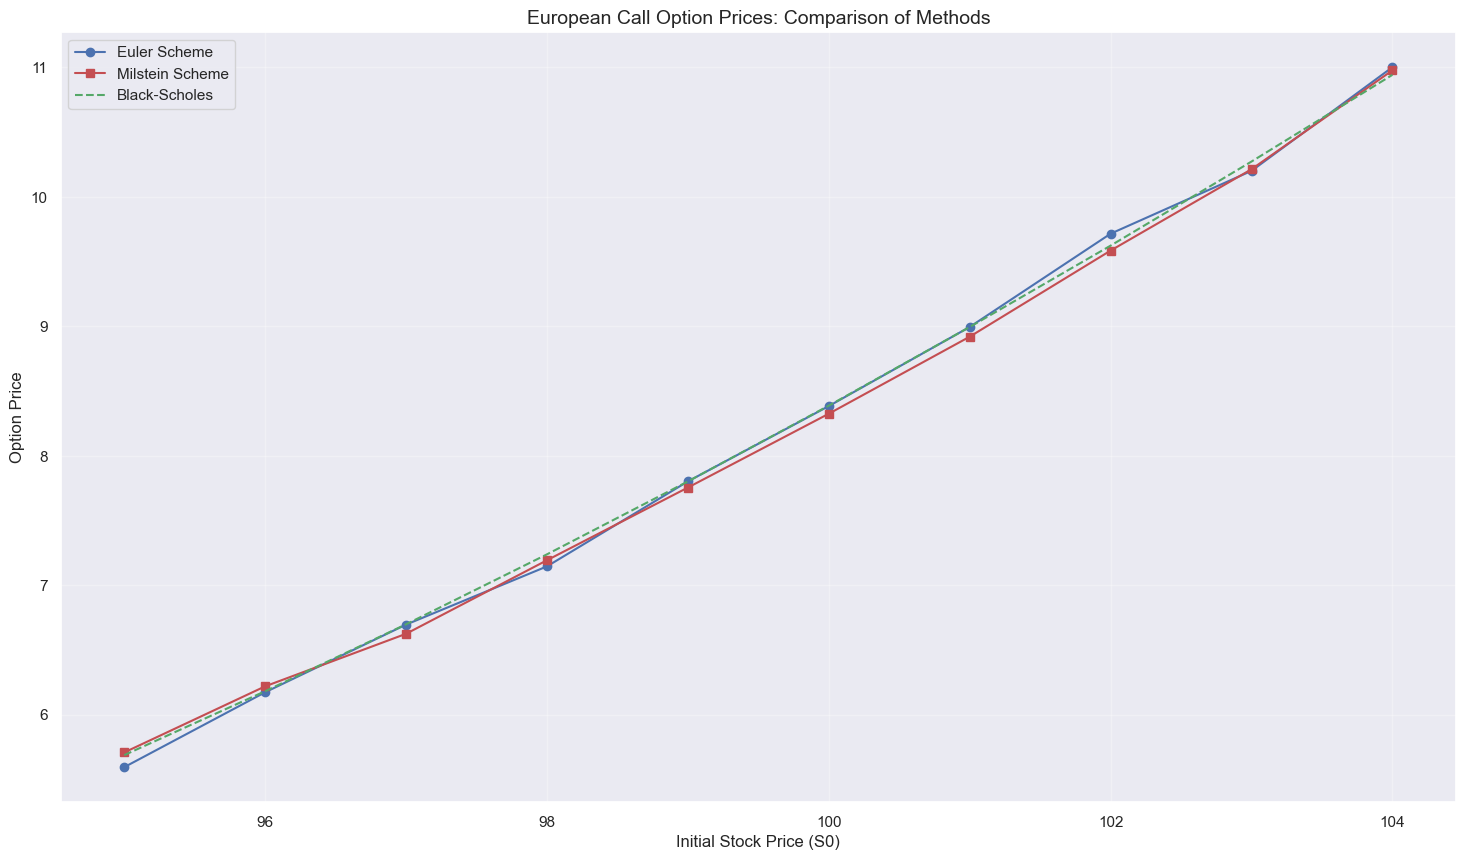

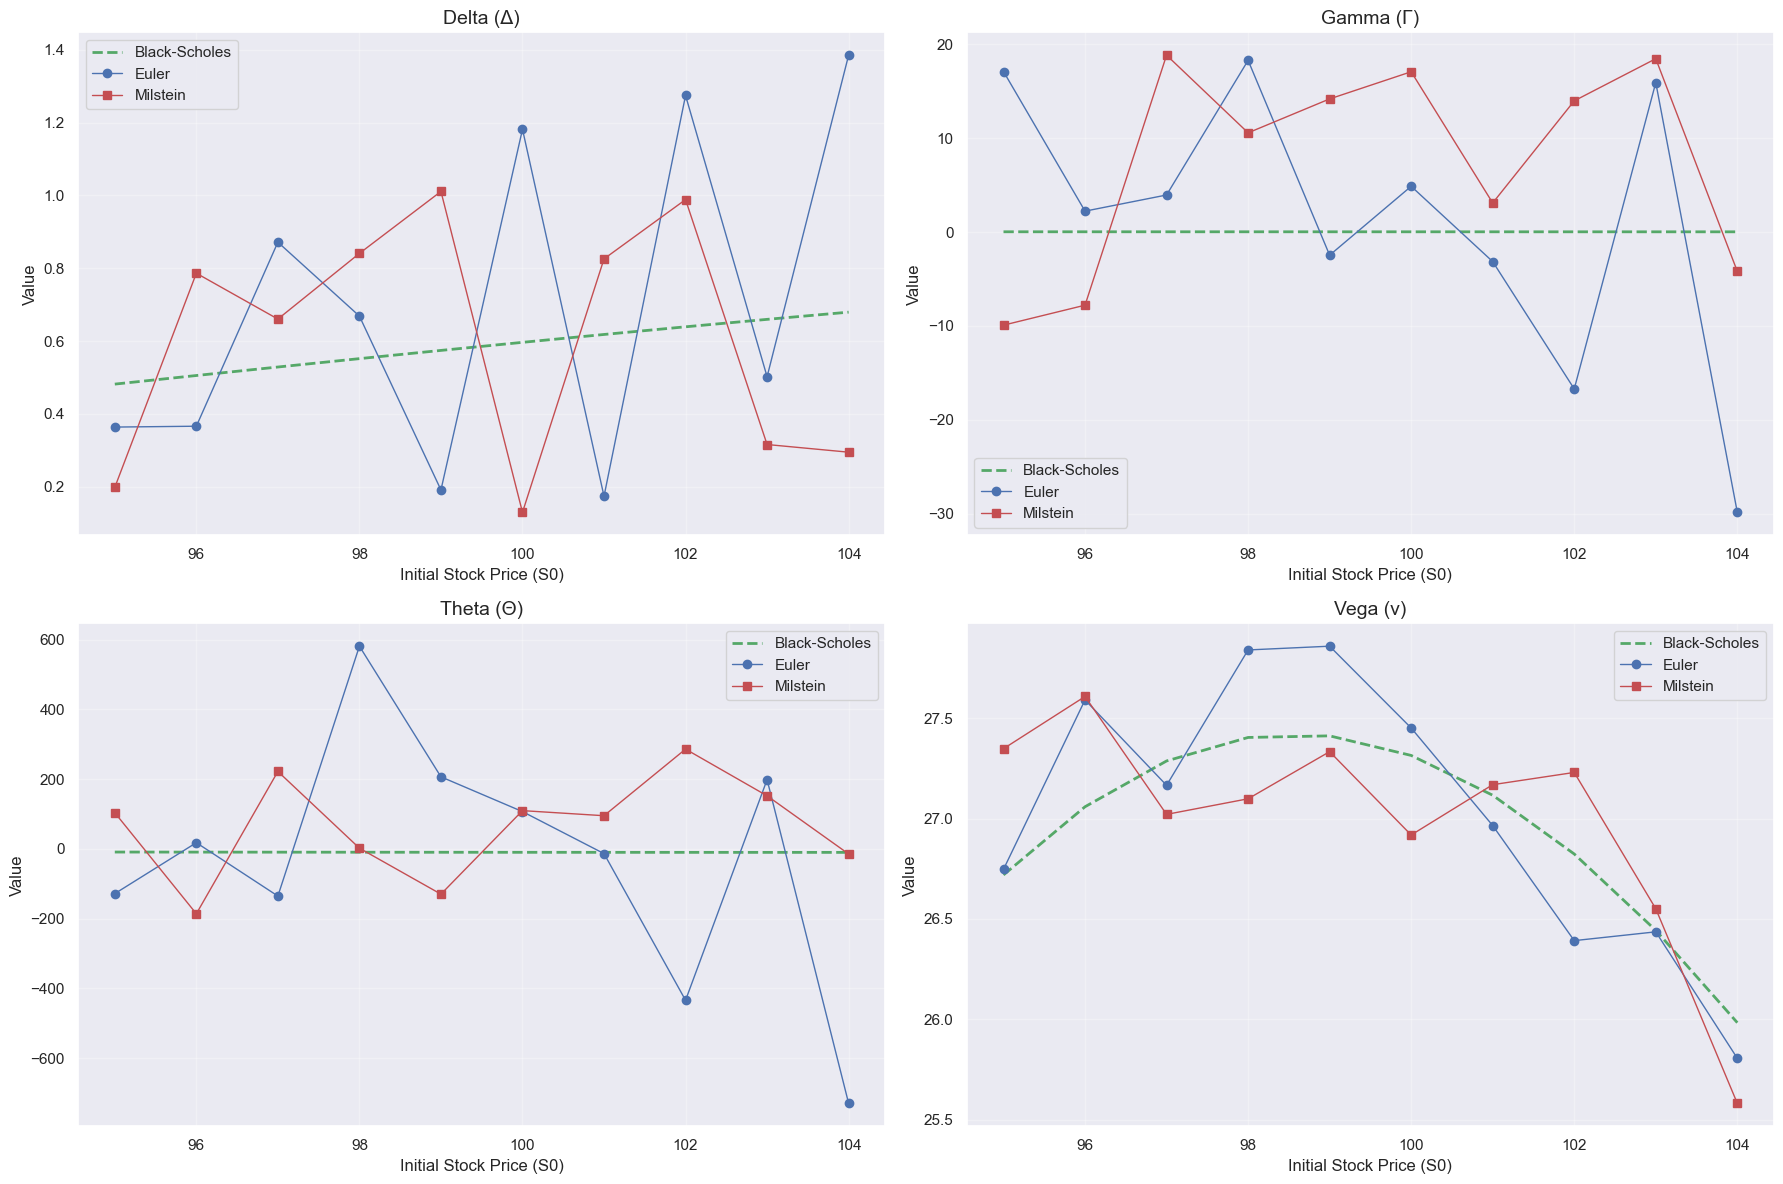

European Call Option Price Comparison (K=100, r=0.055, σ=0.25, T=0.5)
S0	Euler		Milstein	Black-Scholes	Euler SE	Milstein SE


,euler_prices,euler_errors,euler_delta,euler_gamma,euler_theta,euler_vega,milstein_prices,milstein_errors,milstein_delta,milstein_gamma,milstein_theta,milstein_vega,bs_prices,bs_delta,bs_gamma,bs_theta,bs_vega
0,5.5958,0.0450,0.3635,17.0858,-128.1304,26.7468,5.7096,0.0454,0.1979,-9.9161,103.8738,27.3478,5.6889,0.4816,0.0237,-8.8968,26.7189
1,6.1743,0.0473,0.3659,2.2203,17.9481,27.5908,6.2201,0.0476,0.7863,-7.7905,-185.9648,27.6078,6.1823,0.5052,0.0235,-9.0981,27.0586
2,6.6967,0.0495,0.8716,3.9403,-135.1049,27.1653,6.6258,0.0489,0.6603,18.8224,222.2792,27.0206,6.6993,0.5286,0.0232,-9.2756,27.2867
3,7.1464,0.0509,0.6685,18.2720,581.5991,27.8397,7.1937,0.0510,0.8408,10.5580,2.1920,27.0983,7.2394,0.5516,0.0228,-9.4293,27.4038
4,7.8026,0.0534,0.1907,-2.4694,206.8485,27.8584,7.7552,0.0530,1.0110,14.1680,-129.6976,27.3330,7.8023,0.5742,0.0224,-9.5591,27.4118
5,8.3842,0.0552,1.1819,4.8657,107.0985,27.4510,8.3253,0.0550,0.1293,17.0592,109.9033,26.9179,8.3876,0.5964,0.0219,-9.6653,27.3142
6,8.9952,0.0570,0.1734,-3.1511,-13.3804,26.9648,8.9201,0.0568,0.8258,3.0909,95.3250,27.1685,8.9948,0.6180,0.0214,-9.7483,27.1159
7,9.7155,0.0592,1.2748,-16.7054,-434.1067,26.3917,9.5851,0.0589,0.9887,13.9621,286.3479,27.2295,9.6234,0.6391,0.0208,-9.8087,26.8232
8,10.2007,0.0606,0.5018,15.9032,198.7725,26.4354,10.2134,0.0607,0.3156,18.4462,152.4229,26.5506,10.2728,0.6595,0.0201,-9.8474,26.4430
9,11.0016,0.0629,1.3855,-29.8399,-729.6527,25.8056,10.9771,0.0628,0.2945,-4.1870,-14.4481,25.5812,10.9423,0.6793,0.0195,-9.8653,25.9830


In [81]:
def simulate_Wt(dt, steps, N):
    return np.sqrt(dt) * np.random.randn(N, steps)

def euler_discretization_vec(S0, r, sigma, T, steps, N):
    dt = T / steps
    Wt = simulate_Wt(dt, steps, N)
    increments = 1 + r * dt + sigma * Wt
    S_T = S0 * np.prod(increments, axis=1)
    return S_T

def milstein_discretization_vec(S0, r, sigma, T, steps, N):
    dt = T / steps
    Wt = simulate_Wt(dt, steps, N)
    increments = 1 + r * dt + sigma * Wt + 0.5 * sigma**2 * (Wt**2 - dt)
    S_T = S0 * np.prod(increments, axis=1)
    return S_T

def monte_carlo_call_option(S0, K, r, sigma, T, N, steps, discretization_func):
    S_T = discretization_func(S0, r, sigma, T, steps, N)
    payoffs = call_payoff(S_T, K)
    option_price = np.exp(-r * T) * np.mean(payoffs)
    std_error = np.exp(-r * T) * np.std(payoffs) / np.sqrt(N)
    return option_price, std_error

def norm_cdf_approx_vec(x):
    a1, a2, a3, a4, a5 = 0.31938153, -0.356563782, 1.781477937, -1.821255978, 1.330274429
    L = np.abs(x)
    K_inv = 1.0 + 0.2316419 * L
    K = 1.0 / K_inv
    w = 1.0 - (1.0 / np.sqrt(2 * np.pi)) * np.exp(-L**2 / 2.0) * (a1 * K + a2 * K**2 + a3 * K**3 + a4 * K**4 + a5 * K**5)
    return np.where(x >= 0, w, 1.0 - w)

def black_scholes_approx_vec(S0, K, r, sigma, T):
    S0 = np.asarray(S0)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = S0 * norm_cdf_approx_vec(d1) - K * np.exp(-r * T) * norm_cdf_approx_vec(d2)
    return price

K = 100
r = 0.055
sigma = 0.25
T = 0.5
N = 50000
steps = 1000
h = 0.1
h_T = h / 365.0
h_sigma = h

S0_range = np.arange(95, 105, 1)
num_S0 = len(S0_range)

results = {
    'euler': {'prices': np.zeros(num_S0), 'errors': np.zeros(num_S0), 'delta': np.zeros(num_S0), 'gamma': np.zeros(num_S0), 'theta': np.zeros(num_S0), 'vega': np.zeros(num_S0)},
    'milstein': {'prices': np.zeros(num_S0), 'errors': np.zeros(num_S0), 'delta': np.zeros(num_S0), 'gamma': np.zeros(num_S0), 'theta': np.zeros(num_S0), 'vega': np.zeros(num_S0)},
    'bs': {'prices': np.zeros(num_S0), 'delta': np.zeros(num_S0), 'gamma': np.zeros(num_S0), 'theta': np.zeros(num_S0), 'vega': np.zeros(num_S0)}
}

pricing_funcs = {
    'euler': lambda s, k, r_rate, sig, time: monte_carlo_call_option(s, k, r_rate, sig, time, N, steps, euler_discretization_vec)[0],
    'milstein': lambda s, k, r_rate, sig, time: monte_carlo_call_option(s, k, r_rate, sig, time, N, steps, milstein_discretization_vec)[0],
    'bs': black_scholes_approx_vec
}

results['bs']['prices'] = pricing_funcs['bs'](S0_range, K, r, sigma, T)
results['bs']['delta'] = (pricing_funcs['bs'](S0_range + h, K, r, sigma, T) - pricing_funcs['bs'](S0_range - h, K, r, sigma, T)) / (2 * h)
results['bs']['gamma'] = (pricing_funcs['bs'](S0_range + h, K, r, sigma, T) - 2 * results['bs']['prices'] + pricing_funcs['bs'](S0_range - h, K, r, sigma, T)) / h**2
results['bs']['theta'] = (pricing_funcs['bs'](S0_range, K, r, sigma, T - h_T) - results['bs']['prices']) / h_T
results['bs']['vega'] = (pricing_funcs['bs'](S0_range, K, r, sigma + h_sigma, T) - pricing_funcs['bs'](S0_range, K, r, sigma - h_sigma, T)) / (2 * h_sigma)


for i, S0 in enumerate(S0_range):
    for method in ['euler', 'milstein']:
        price_func = pricing_funcs[method]
        results[method]['prices'][i], results[method]['errors'][i] = monte_carlo_call_option(S0, K, r, sigma, T, N, steps, globals()[f'{method}_discretization_vec'])

        price_S_plus = price_func(S0 + h, K, r, sigma, T)
        price_S_minus = price_func(S0 - h, K, r, sigma, T)
        results[method]['delta'][i] = (price_S_plus - price_S_minus) / (2 * h)
        results[method]['gamma'][i] = (price_S_plus - 2 * results[method]['prices'][i] + price_S_minus) / h**2

        price_T_minus = price_func(S0, K, r, sigma, T - h_T) if T > h_T else results[method]['prices'][i] # Avoid negative time
        results[method]['theta'][i] = (price_T_minus - results[method]['prices'][i]) / h_T

        price_sigma_plus = price_func(S0, K, r, sigma + h_sigma, T)
        price_sigma_minus = price_func(S0, K, r, sigma - h_sigma, T) if sigma > h_sigma else price_func(S0, K, r, 1e-6, T) # Avoid non-positive sigma
        results[method]['vega'][i] = (price_sigma_plus - price_sigma_minus) / (2 * h_sigma)


plt.figure(figsize=(18, 10))
plt.plot(S0_range, results['euler']['prices'], 'bo-', label='Euler Scheme')
plt.plot(S0_range, results['milstein']['prices'], 'rs-', label='Milstein Scheme')
plt.plot(S0_range, results['bs']['prices'], 'g--', label='Black-Scholes')
plt.xlabel('Initial Stock Price (S0)', fontsize=12)
plt.ylabel('Option Price', fontsize=12)
plt.title('European Call Option Prices: Comparison of Methods', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


fig, axs = plt.subplots(2, 2, figsize=(18, 12))
titles = ['Delta (Δ)', 'Gamma (Γ)', 'Theta (Θ)', 'Vega (ν)']
greeks = ['delta', 'gamma', 'theta', 'vega']
method_names = ['Black-Scholes', 'Euler', 'Milstein']
method_keys = ['bs', 'euler', 'milstein']
method_colors = ['g', 'b', 'r']
method_markers = ['--', 'o-', 's-']


for i, (ax, title, greek) in enumerate(zip(axs.flatten(), titles, greeks)):
    for j, (method_key, method_name, color, marker) in enumerate(zip(method_keys, method_names, method_colors, method_markers)):
         ax.plot(S0_range, results[method_key][greek], marker, color=color, linewidth=2 if marker=='--' else 1, label=method_name)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Initial Stock Price (S0)', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Print numerical results for comparison
print("European Call Option Price Comparison (K=100, r=0.055, σ=0.25, T=0.5)")
print("S0\tEuler\t\tMilstein\tBlack-Scholes\tEuler SE\tMilstein SE")

results_df = pd.DataFrame()
for k in results.keys():
    df = pd.DataFrame(results[k]).round(4)
    df.columns = [f"{k}_{col}" for col in df.columns]
    results_df = pd.concat([results_df, df], axis=1)
results_df

## 6

Consider the following 2-factor model for stock prices with stochastic volatility:

$$
dS_t = r S_t \, dt + \sqrt{V_t} S_t \, dW_t^1
$$

$$
dV_t = \alpha (\beta - V_t) \, dt + \sigma \sqrt{V_t} \, dW_t^2
$$

where the Brownian Motion processes above are correlated:  
$dW_t^1 dW_t^2 = \rho \, dt$, where the correlation $\rho$ is a constant in $[-1,1]$.

Estimate the price of a European Call option (via Monte Carlo simulation) that has a strike price of $X$ and matures in $T$ years.

Use the following default parameters of the model:  
$\rho = -0.6$, $r = 0.055$, $S_0 = \$100$, $X = \$100$, $V_0 = 0.05$, $\sigma = 0.42$, $\alpha = 5.8$, $\beta = 0.0625$, $dt = 0.05$, $N = 10,000$.

Use the Full Truncation, Partial Truncation, and Reflection methods, and provide 3 price estimates by using the three methods.

### Inputs
$\rho$, $r$, $S_0$, $V_0$, $\sigma$, $\alpha$, $\beta$

### Outputs
Values: $C_1$, $C_2$, $C_3$

In [83]:
def simulate_Wt_correlated(T, N, n, rho):
    dt = T / N
    dW1 = np.random.normal(0.0, np.sqrt(dt), (n, N))
    dW2 = np.random.normal(0.0, np.sqrt(dt), (n, N))
    dW2 = rho * dW1 + np.sqrt(1 - rho**2) * dW2
    return dW1, dW2

def two_factor_gbm_vec(S0, V0, r, alpha, beta, sigma, rho, T, N, n, method="partial_truncation"):
    dt = T / N
    S_paths = np.zeros((n, N + 1))
    V_paths = np.zeros((n, N + 1))
    S_paths[:, 0] = S0
    V_paths[:, 0] = V0

    dW1, dW2 = simulate_Wt_correlated(T, N, n, rho)

    for t in range(N):
        S = S_paths[:, t]
        V = V_paths[:, t]
        sqrt_V = np.sqrt(np.maximum(V, 0))
        S_paths[:, t + 1] = S * np.exp((r - 0.5 * V) * dt + sqrt_V * dW1[:, t])

        if method == "full_truncation":
            V_next = V + alpha * (beta - V) * dt + sigma * sqrt_V * dW2[:, t]
            V_paths[:, t + 1] = np.maximum(V_next, 0)
        elif method == "partial_truncation":
            V_next = V + alpha * (beta - V) * dt + sigma * sqrt_V * dW2[:, t]
            V_paths[:, t + 1] = np.maximum(V_next, 0)
        elif method == "reflection":
            V_next = V + alpha * (beta - V) * dt + sigma * sqrt_V * dW2[:, t]
            V_paths[:, t + 1] = np.abs(V_next)
        else:
             raise ValueError("Unsupported method. Choose 'full_truncation', 'partial_truncation', or 'reflection'.")


    return S_paths[:, -1]

def european_call_option_price_two_factor_vec(S0, V0, r, alpha, beta, sigma, rho, K, T, N, n, method="partial_truncation"):
    S_T = two_factor_gbm_vec(S0, V0, r, alpha, beta, sigma, rho, T, N, n, method)
    C_T = call_payoff(S_T, K)
    C_0 = np.exp(-r * T) * np.mean(C_T)
    std_error = np.exp(-r * T) * np.std(C_T) / np.sqrt(n)
    return C_0, std_error

S0 = 100
V0 = 0.05
r = 0.055
alpha = 5.8
beta = 0.0625
sigma = 0.42
rho = -0.6
K = 100
T = 1
n = 10000
N = 1000

methods = ["full_truncation", "partial_truncation", "reflection"]
results = {}

for method in methods:
    price, se = european_call_option_price_two_factor_vec(S0, V0, r, alpha, beta, sigma, rho, K, T, N, n, method=method)
    results[method] = {'price': price, 'std_error': se}
    print(f"{method.replace('_', ' ').title()} Method: Call Price = ${price:.4f}, Std Error = {se:.4f}")

Full Truncation Method: Call Price = $12.5335, Std Error = 0.1683
Partial Truncation Method: Call Price = $12.1695, Std Error = 0.1625
Reflection Method: Call Price = $12.7187, Std Error = 0.1683


## 7

The objective of this exercise is to compare a sample of Pseudo-Random numbers with a sample of Quasi-Monte Carlo numbers of $\text{Uniform}[0,1] \times [0,1]$:

Use 2-dimensional Halton sequences to estimate the following integral:

$$
I = \int_0^1 \int_0^1 e^{-xy} \left( \sin(6\pi x) + \cos(32\pi y) \right)^{\frac{1}{3}} \, dx \, dy
$$

Default parameter values: $N = 10,000$; $(2,3)$ for bases.

### Inputs
$b_1$, $b_2$ (the bases), $N$

### Outputs
$I$

In [12]:
def halton(index, base):
    result = 0.0
    f = 1.0 / base
    i = index
    while i > 0:
        result += f * (i % base)
        i //= base
        f /= base
    return result

def integrand(x, y):
    return np.exp(-x * y) * (np.sin(6 * np.pi * x) + np.cbrt(np.cos(2 * np.pi * y)))

def estimate_integral_halton(params):
    b1, b2 = params['bases']
    N = params['N']

    indices = np.arange(1, N + 1)
    x_coords = np.array([halton(i, b1) for i in indices])
    y_coords = np.array([halton(i, b2) for i in indices])

    integrand_values = integrand(x_coords, y_coords)
    integral_estimate = np.mean(integrand_values)

    results = {
        'params': params,
        'estimated_integral': integral_estimate
    }
    return results

parameters = {
    'bases': (2, 3),
    'N': 10000
}

estimation_result = estimate_integral_halton(parameters)

print(f"Parameters: {estimation_result['params']}")
print(f"Estimated Integral (I): {estimation_result['estimated_integral']:.8f}")

Parameters: {'bases': (2, 3), 'N': 10000}
Estimated Integral (I): 0.02626197


In [13]:
estimation_uniform = np.mean(integrand(np.random.uniform(0,1,10000),np.random.uniform(0,1,10000)))

In [14]:
estimation_uniform

0.023244040022438465